# VPINS — AIA Challenge: Training — CLONE thử nghiệm (ranking ĐÃ dedupe, K=10–30)

> **Clone thử nghiệm.** Khác bản chính: pool đặc trưng đọc từ **`feature_set_dedup.json`**
> (`consensus_rank` ĐÃ khử đa cộng tuyến — 80 feature) và quét **K∈[10,30]**. Output ghi ra
> `submission_800_dedup.txt` / `figures/TRD*` (KHÔNG đụng bản chính). Mục tiêu: so CatBoost trên
> ranking dedupe vs bản hiện tại (CatBoost K=17, meanK 192.96).

Notebook training: với pool đặc trưng đã xếp hạng + **khử đa cộng tuyến** (`consensus_rank` dedupe), **quét số feature K∈[10,30] như một hyperparameter trong Optuna** cho từng mô hình, rồi **chọn 1 mô hình đơn tốt nhất** (không ensemble) để sinh file nộp.

**Lá chắn chống chọn-lệch:**
- Đánh giá **grouped OOF** (StratifiedGroupKFold theo profile) — không leakage.
- Metric chính **`mean_hits_over_k`** (trung bình hits ở top 15–25%), bền hơn hits@20% đơn lẻ.
- Chọn cuối theo **1-SE rule**: ưu tiên mô hình **đơn giản hơn** (ít feature / tuyến tính) nếu nằm trong 1 sai số chuẩn của bộ tốt nhất.
- Báo cáo **meanK ± SE** (lặp nhiều seed) + ghi chú optimism.

**Mô hình:** LightGBM, XGBoost, CatBoost, LogReg, LDA. **~40 trials/model**.

## 0. Setup & cấu hình

In [1]:
import warnings, os, sys, time, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sys.path.insert(0, os.getcwd())

from src.data import load_data, TARGET, disp, NAME
from src.features import build_features_v2, load_feature_set, make_preprocessor, encoded_layout
from src.cv import profile_groups, oof_proba, build_pipeline
from src.tune import tune_model_k, build_final_spec
from src.predict import fit_full, score_test, make_submission, verify_submission
from src.metrics import summarize, mean_hits_over_k, topk_hits

plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "Tahoma", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
FIG = Path("figures"); FIG.mkdir(exist_ok=True); Path("outputs").mkdir(exist_ok=True)
def savefig(n): plt.savefig(FIG / (n + ".png"), dpi=150, bbox_inches="tight")

K_RANGE = (10, 30)
N_TRIALS = 40
N_REPEATS_FINAL = 5
SEED = 42
MODELS = ["LightGBM", "XGBoost", "CatBoost", "LogReg", "LDA"]
print("Config:", dict(K_RANGE=K_RANGE, N_TRIALS=N_TRIALS, N_REPEATS_FINAL=N_REPEATS_FINAL))

Config: {'K_RANGE': (10, 30), 'N_TRIALS': 40, 'N_REPEATS_FINAL': 5}


In [2]:
train, test = load_data()
Xtr, Xte, ENG = build_features_v2(train, test)
y = train[TARGET].astype(int); pos_rate = y.mean()
GROUPS = profile_groups(Xtr)
POOL = load_feature_set("consensus_rank", path="outputs/feature_set_dedup.json")     # 80 feature (consensus ĐÃ khử đa cộng tuyến)
test_ids = test["ID"].values
print(f"Train {Xtr.shape} | Test {Xte.shape} | dương {pos_rate:.4f} | profiles {len(np.unique(GROUPS))}")
print(f"Pool đặc trưng: {len(POOL)} | top10: {[disp(c) for c in POOL[:10]]}")
print(f"Quét K trong {K_RANGE} (top-K theo consensus).")

Train (5822, 127) | Test (4000, 126) | dương 0.0598 | profiles 5171
Pool đặc trưng: 80 | top10: ['Đóng phí BH ô tô', 'Tổng mức đóng phí BH khác', 'Nhóm KH chính (main type)', 'Đóng phí BH cháy nổ', 'Thu nhập × sức mua', 'Học vấn thấp', 'Thu nhập TB', 'Số loại BH có đóng phí', 'Đóng phí BH thuyền', 'Đã kết hôn']
Quét K trong (10, 30) (top-K theo consensus).


## 2. Tuning từng mô hình — K là hyperparameter

Mỗi mô hình một study Optuna; mỗi trial chọn **K∈[15,30]** + tham số mô hình, chấm bằng grouped OOF `mean_hits_over_k`. Boosting dùng early stopping trong fold.

In [3]:
tuned = {}   # name -> dict(bp, K, val, mean_iter, spec)

In [4]:
# ===== Tuning LightGBM (K là hyperparameter) =====
t0 = time.time()
bp, K, val, mi, study = tune_model_k("LightGBM", Xtr, y, POOL, pos_rate, k_range=K_RANGE,
                                     n_trials=N_TRIALS, n_splits=5, seed=SEED, groups=GROUPS,
                                     objective="hits_meanK")
spec = build_final_spec("LightGBM", bp, K, mi, pos_rate, seed=SEED)
tuned["LightGBM"] = dict(bp=bp, K=K, val=val, mean_iter=mi, spec=spec, study=study)
print(f"LightGBM: bestK={K} | meanK(obj)={val:.1f} | {time.time()-t0:.0f}s")
print("   tham số:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bp.items()})

LightGBM: bestK=14 | meanK(obj)=189.2 | 93s
   tham số: {'learning_rate': 0.0462, 'num_leaves': 57, 'max_depth': 11, 'min_child_samples': 100, 'subsample': 0.9102, 'colsample_bytree': 0.6032, 'reg_alpha': 0.2546, 'reg_lambda': 0.9609, 'scale_pos_weight': 1.0}


In [5]:
# ===== Tuning XGBoost (K là hyperparameter) =====
t0 = time.time()
bp, K, val, mi, study = tune_model_k("XGBoost", Xtr, y, POOL, pos_rate, k_range=K_RANGE,
                                     n_trials=N_TRIALS, n_splits=5, seed=SEED, groups=GROUPS,
                                     objective="hits_meanK")
spec = build_final_spec("XGBoost", bp, K, mi, pos_rate, seed=SEED)
tuned["XGBoost"] = dict(bp=bp, K=K, val=val, mean_iter=mi, spec=spec, study=study)
print(f"XGBoost: bestK={K} | meanK(obj)={val:.1f} | {time.time()-t0:.0f}s")
print("   tham số:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bp.items()})

XGBoost: bestK=15 | meanK(obj)=196.0 | 110s
   tham số: {'learning_rate': 0.0433, 'max_depth': 9, 'min_child_weight': 10, 'subsample': 0.6051, 'colsample_bytree': 0.7551, 'gamma': 0.0259, 'reg_alpha': 0.1355, 'reg_lambda': 0.635, 'scale_pos_weight': 3.9661}


In [6]:
# ===== Tuning CatBoost (K là hyperparameter) =====
t0 = time.time()
bp, K, val, mi, study = tune_model_k("CatBoost", Xtr, y, POOL, pos_rate, k_range=K_RANGE,
                                     n_trials=N_TRIALS, n_splits=5, seed=SEED, groups=GROUPS,
                                     objective="hits_meanK")
spec = build_final_spec("CatBoost", bp, K, mi, pos_rate, seed=SEED)
tuned["CatBoost"] = dict(bp=bp, K=K, val=val, mean_iter=mi, spec=spec, study=study)
print(f"CatBoost: bestK={K} | meanK(obj)={val:.1f} | {time.time()-t0:.0f}s")
print("   tham số:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bp.items()})

CatBoost: bestK=14 | meanK(obj)=193.4 | 175s
   tham số: {'learning_rate': 0.0978, 'depth': 4, 'l2_leaf_reg': 19.6226, 'random_strength': 0.0333}


In [7]:
# ===== Tuning LogReg (K là hyperparameter) =====
t0 = time.time()
bp, K, val, mi, study = tune_model_k("LogReg", Xtr, y, POOL, pos_rate, k_range=K_RANGE,
                                     n_trials=N_TRIALS, n_splits=5, seed=SEED, groups=GROUPS,
                                     objective="hits_meanK")
spec = build_final_spec("LogReg", bp, K, mi, pos_rate, seed=SEED)
tuned["LogReg"] = dict(bp=bp, K=K, val=val, mean_iter=mi, spec=spec, study=study)
print(f"LogReg: bestK={K} | meanK(obj)={val:.1f} | {time.time()-t0:.0f}s")
print("   tham số:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bp.items()})

LogReg: bestK=29 | meanK(obj)=182.6 | 65s
   tham số: {'C': 0.3517, 'penalty': 'l1', 'class_weight': None}


In [8]:
# ===== Tuning LDA (K là hyperparameter) =====
t0 = time.time()
bp, K, val, mi, study = tune_model_k("LDA", Xtr, y, POOL, pos_rate, k_range=K_RANGE,
                                     n_trials=N_TRIALS, n_splits=5, seed=SEED, groups=GROUPS,
                                     objective="hits_meanK")
spec = build_final_spec("LDA", bp, K, mi, pos_rate, seed=SEED)
tuned["LDA"] = dict(bp=bp, K=K, val=val, mean_iter=mi, spec=spec, study=study)
print(f"LDA: bestK={K} | meanK(obj)={val:.1f} | {time.time()-t0:.0f}s")
print("   tham số:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bp.items()})

LDA: bestK=30 | meanK(obj)=182.8 | 46s
   tham số: {'shrinkage': 0.2579}


## 3. Đánh giá trung thực + chọn mô hình cuối (1-SE rule)

Với mỗi mô hình đã tune: grouped OOF lặp `N_REPEATS_FINAL` seed → `mean_hits_over_k` ± **SE**, kèm hits@20% & AUC. Áp **1-SE rule**: trong các mô hình nằm trong 1 SE của bộ tốt nhất, ưu tiên **ít feature hơn**, rồi **tuyến tính**.

In [9]:
def eval_repeats(spec, cols, n_rep=N_REPEATS_FINAL):
    mks = []
    for r in range(n_rep):
        o, _ = oof_proba(spec, Xtr, y, cols, n_repeats=1, seed=SEED + r, groups=GROUPS)
        mks.append(mean_hits_over_k(y, o))
    o_avg, _ = oof_proba(spec, Xtr, y, cols, n_repeats=n_rep, seed=SEED, groups=GROUPS)
    s = summarize(y, o_avg)
    return float(np.mean(mks)), float(np.std(mks) / np.sqrt(n_rep)), s

rows = []
for nm in MODELS:
    d = tuned[nm]; mk, se, s = eval_repeats(d["spec"], POOL[:d["K"]])
    rows.append({"model": nm, "K": d["K"], "meanK": mk, "SE": se,
                 "hits@20%": s["hits@20%"], "AUC": s["AUC"],
                 "linear": nm in ("LogReg", "LDA")})
res = pd.DataFrame(rows).sort_values("meanK", ascending=False).reset_index(drop=True)
print(res.round(4).to_string(index=False))

# 1-SE rule
best = res.iloc[0]; thr = best["meanK"] - best["SE"]
cand = res[res["meanK"] >= thr].copy()
cand = cand.sort_values(["K", "linear", "meanK"], ascending=[True, False, False])   # ít feature -> tuyến tính -> meanK
FINAL = cand.iloc[0]["model"]
res["selected"] = res["model"] == FINAL
res.to_csv("outputs/training_results_dedup.csv", index=False, encoding="utf-8-sig")
print(f"\nBest meanK={best['meanK']:.1f} (±{best['SE']:.1f}) -> ngưỡng 1-SE={thr:.1f}")
print(f"Ứng viên trong 1-SE: {list(cand['model'])}")
print(f"=> CHỌN (1-SE rule, ưu tiên gọn): {FINAL}  (K={int(tuned[FINAL]['K'])})")

   model  K  meanK     SE  hits@20%    AUC  linear
 XGBoost 15 195.96 1.9002       209 0.7877   False
LightGBM 14 195.12 0.9775       206 0.7843   False
CatBoost 14 190.32 0.9254       191 0.7900   False
     LDA 30 182.60 0.1386       186 0.7575    True
  LogReg 29 181.36 0.5228       184 0.7654    True

Best meanK=196.0 (±1.9) -> ngưỡng 1-SE=194.1
Ứng viên trong 1-SE: ['LightGBM', 'XGBoost']
=> CHỌN (1-SE rule, ưu tiên gọn): LightGBM  (K=14)


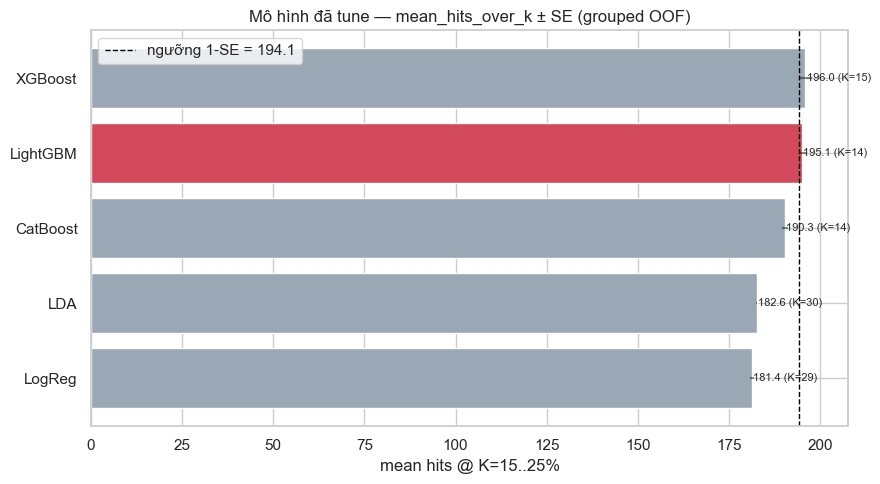

In [10]:
# TRD01 — meanK ± SE theo mô hình
fig, ax = plt.subplots(figsize=(9, 5))
r = res.sort_values("meanK")
colors = ["#d1495b" if m == FINAL else "#9aa7b5" for m in r["model"]]
ax.barh(r["model"], r["meanK"], xerr=r["SE"], color=colors, error_kw=dict(alpha=.5))
ax.axvline(thr, color="black", ls="--", lw=1, label=f"ngưỡng 1-SE = {thr:.1f}")
for i, (mk, k_) in enumerate(zip(r["meanK"], r["K"])):
    ax.text(mk + 0.3, i, f"{mk:.1f} (K={int(k_)})", va="center", fontsize=8)
ax.set_title("Mô hình đã tune — mean_hits_over_k ± SE (grouped OOF)")
ax.set_xlabel("mean hits @ K=15..25%"); ax.legend()
plt.tight_layout(); savefig("TRD01_model_select"); plt.show()

## 4. Minh bạch ảnh hưởng của K

Dù K được tune ẩn trong Optuna, trích các trial để xem **objective tốt nhất theo từng K** — cho thấy vùng K hiệu quả (câu chuyện 15–30).

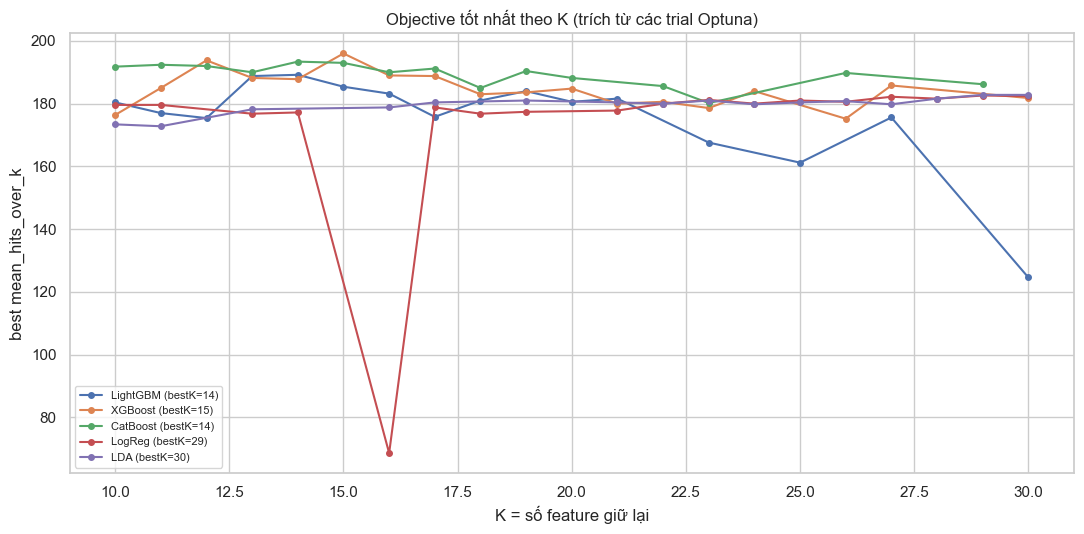

In [11]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for nm in MODELS:
    st = tuned[nm]["study"]
    df = pd.DataFrame([{"K": t.params.get("K"), "val": t.value}
                       for t in st.trials if t.value is not None and "K" in t.params])
    if len(df):
        g = df.groupby("K")["val"].max()
        ax.plot(g.index, g.values, marker="o", ms=4, label=f"{nm} (bestK={tuned[nm]['K']})")
ax.set_title("Objective tốt nhất theo K (trích từ các trial Optuna)")
ax.set_xlabel("K = số feature giữ lại"); ax.set_ylabel("best mean_hits_over_k")
ax.legend(fontsize=8)
plt.tight_layout(); savefig("TRD02_K_effect"); plt.show()

## 5. Mô hình cuối → `submission_800_dedup.txt`

Refit mô hình đã chọn trên toàn train → chấm điểm 4.000 test → top 800 ID.

Mô hình cuối: LightGBM | K=14 | tham số: {'learning_rate': 0.04623480853501848, 'num_leaves': 57, 'max_depth': 11, 'min_child_samples': 100, 'subsample': 0.9102488032447613, 'colsample_bytree': 0.6031585109382561, 'reg_alpha': 0.2546283806218223, 'reg_lambda': 0.960900025786457, 'scale_pos_weight': 1.0}
Kiểm tra file nộp: {'đủ k dòng': True, 'ID duy nhất': True, 'trong [1,4000]': True}
5 ID điểm cao nhất: [1468, 2844, 1243, 166, 2622]


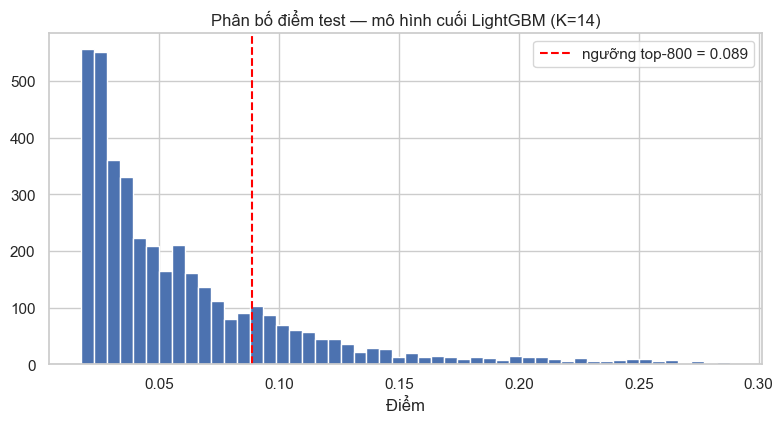

Kỳ vọng (grouped OOF): lift@20% ~ 2.96x -> ~141 người mua trong 800 chọn (so ~48 nếu ngẫu nhiên).


In [12]:
d = tuned[FINAL]; FK = d["K"]; COLS = POOL[:FK]
pipe = fit_full(d["spec"], Xtr, y, COLS)
test_score = score_test(pipe, Xte)
top800, full = make_submission(test_score, test_ids, k=800,
                               out_path="submission_800_dedup.txt", full_csv="outputs/test_scores_dedup.csv")
ok, ids = verify_submission("submission_800_dedup.txt")
print(f"Mô hình cuối: {FINAL} | K={FK} | tham số: {d['bp']}")
print("Kiểm tra file nộp:", ok)
print("5 ID điểm cao nhất:", top800["ID"].head().tolist())

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.hist(full["score"], bins=50, color="#4c72b0", edgecolor="white")
thr = full.iloc[799]["score"]
ax.axvline(thr, color="red", ls="--", label=f"ngưỡng top-800 = {thr:.3f}")
ax.set_title(f"Phân bố điểm test — mô hình cuối {FINAL} (K={FK})"); ax.set_xlabel("Điểm"); ax.legend()
plt.tight_layout(); savefig("TRD03_final_score_dist"); plt.show()
lift = summarize(y, oof_proba(d["spec"], Xtr, y, COLS, n_repeats=N_REPEATS_FINAL, groups=GROUPS)[0])["lift@20%"]
print(f"Kỳ vọng (grouped OOF): lift@20% ~ {lift:.2f}x -> ~{lift*pos_rate*800:.0f} người mua trong 800 chọn "
      f"(so ~{pos_rate*800:.0f} nếu ngẫu nhiên).")

## 6. Giải thích mô hình cuối (đầu vào Nhiệm vụ 2)

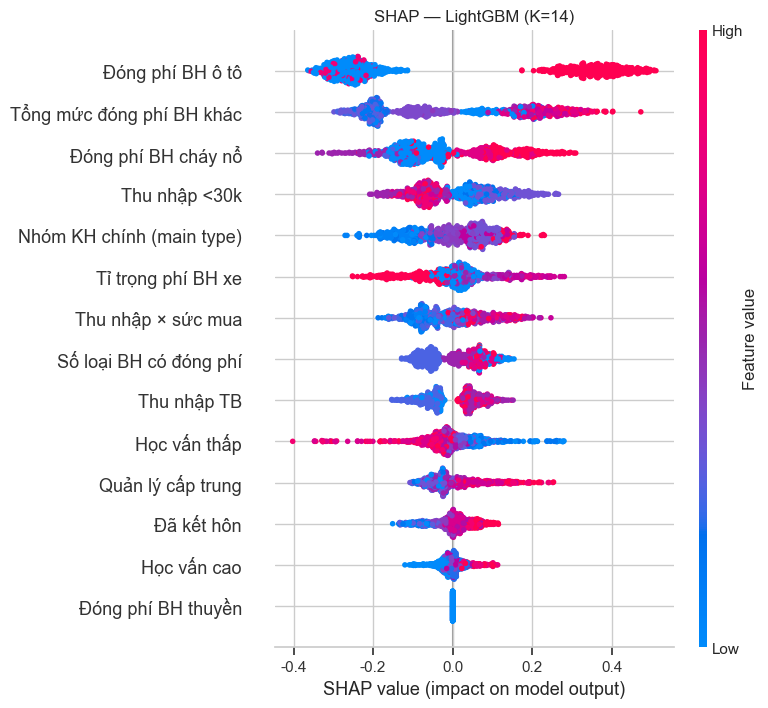

In [13]:
pre = pipe.named_steps["pre"]; clf = pipe.named_steps["clf"]
Xenc = pre.transform(Xtr)
feat_names = [disp(c) for c in encoded_layout(COLS)[0]]
if FINAL in ("LightGBM", "XGBoost", "CatBoost"):
    try:
        import shap
        si = np.random.RandomState(0).choice(len(Xenc), min(1000, len(Xenc)), replace=False)
        sv = shap.TreeExplainer(clf).shap_values(Xenc[si])
        sv1 = sv[1] if isinstance(sv, list) else sv
        shap.summary_plot(sv1, Xenc[si], feature_names=feat_names, show=False, max_display=15)
        plt.title(f"SHAP — {FINAL} (K={FK})"); savefig("TRD04_explain"); plt.show()
    except Exception as e:
        print("SHAP lỗi:", str(e)[:100])
else:
    coef = clf.coef_[0]
    imp = pd.Series(coef, index=feat_names).sort_values()
    sel = pd.concat([imp.head(8), imp.tail(8)])
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(sel.index, sel.values, color=["#d1495b" if v > 0 else "#9aa7b5" for v in sel.values])
    ax.axvline(0, color="black", lw=.8)
    ax.set_title(f"Hệ số {FINAL} (K={FK}) — dương = tăng khả năng mua AIA"); ax.tick_params(labelsize=8)
    plt.tight_layout(); savefig("TRD04_explain"); plt.show()
    print("Top yếu tố tăng khả năng mua:", list(imp.tail(5).index[::-1]))

## 7. Tổng kết

In [14]:
print("="*64); print("TỔNG KẾT TRAINING — VPINS AIA"); print("="*64)
print(f"Mô hình cuối: {FINAL} | K={FK} feature (consensus top-{FK})")
print(f"grouped OOF: meanK={res[res.model==FINAL]['meanK'].iloc[0]:.1f} ± {res[res.model==FINAL]['SE'].iloc[0]:.1f}"
      f" | hits@20%={int(res[res.model==FINAL]['hits@20%'].iloc[0])} | AUC={res[res.model==FINAL]['AUC'].iloc[0]:.4f}")
print("\nBảng so sánh các mô hình (outputs/training_results_dedup.csv):")
print(res.round(4).to_string(index=False))
print("\nFile: submission_800_dedup.txt | outputs/test_scores_dedup.csv | figures/TRD01..TRD04")
print("Lưu ý: meanK là OOF trung thực; vẫn có optimism nhẹ do chọn max trên 5 mô hình -> coi như cận trên.")

TỔNG KẾT TRAINING — VPINS AIA
Mô hình cuối: LightGBM | K=14 feature (consensus top-14)
grouped OOF: meanK=195.1 ± 1.0 | hits@20%=206 | AUC=0.7843

Bảng so sánh các mô hình (outputs/training_results_dedup.csv):
   model  K  meanK     SE  hits@20%    AUC  linear  selected
 XGBoost 15 195.96 1.9002       209 0.7877   False     False
LightGBM 14 195.12 0.9775       206 0.7843   False      True
CatBoost 14 190.32 0.9254       191 0.7900   False     False
     LDA 30 182.60 0.1386       186 0.7575    True     False
  LogReg 29 181.36 0.5228       184 0.7654    True     False

File: submission_800_dedup.txt | outputs/test_scores_dedup.csv | figures/TRD01..TRD04
Lưu ý: meanK là OOF trung thực; vẫn có optimism nhẹ do chọn max trên 5 mô hình -> coi như cận trên.
